# REPT cohort tuning results — top-10 by fade signal

REPT has two characterization snapshots per cell (workbook batch 1 + batch 2), so
the calibration target is a **measured** per-cell fade rate, not a regression
from the longterm CSV. The longterm CSV serves as **independent validation**.

Pipeline (per [Voltaris/scripts/rept_sweep.py](../scripts/rept_sweep.py)):

1. Load `char_b1` and `char_b2` for the cell
2. `target_slope = -(SoH_b1 - SoH_b2) / cycles_per_batch * 100`  (pp/100cy)
3. Pre-age PyBaMM to `SoH_b1` (clamped to [0.5, 1.0])
4. Calibrate SEI diffusivity to match `target_slope`
5. Compare to longterm CSV regression slope (independent check)

**Expected pattern**: CSV slope steeper than workbook target (early-cycle fade > long-run average).
Flagged via `CSV_VS_WORKBOOK_DISAGREE` only when the ratio > 3×.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path("/home/hj/Desktop/PINNs").resolve()
OUT_DIR = REPO_ROOT / "Voltaris/outputs/tuned_params"
LONGTERM_DIR = REPO_ROOT / "Data/Longterm"
assert OUT_DIR.exists()
print(f"Reading artifacts from {OUT_DIR}")

Reading artifacts from /home/hj/Desktop/PINNs/Voltaris/outputs/tuned_params


## 1. Cohort summary table

Includes the workbook b1/b2 SoH pair, the slopes from all three sources
(workbook target, longterm CSV, calibrated sim), and any gates fired.

In [2]:
rows = []
for p in sorted(OUT_DIR.glob("REPT_*_aging_calibrated.json")):
    d = json.loads(p.read_text())
    rows.append({
        "cell": d["cell"],
        "SoH_b1 (%)": d["soh_b1_pct"],
        "SoH_b2 (%)": d["soh_b2_pct"],
        "fade (pp)": d["fade_b1_to_b2_pp"],
        "target slope": d["target_slope_pp_per_100cy"],
        "CSV slope": d.get("csv_slope_pp_per_100cy"),
        "sim slope": d.get("sim_slope_pp_per_100cy"),
        "D_SEI (m²/s)": d["calibrated_value"],
        "rel err (%)": d["relative_error_pct"],
        "classification": d["classification"],
        "gates": ", ".join(g for g, v in (d.get("gate_audit") or {}).items()
                            if isinstance(v, dict) and v.get("tripped")) or "–",
    })
df = pd.DataFrame(rows).sort_values("fade (pp)", ascending=False)
display(df.style.format({
    "SoH_b1 (%)": "{:.2f}", "SoH_b2 (%)": "{:.2f}",
    "fade (pp)": "{:+.2f}", "target slope": "{:+.4f}",
    "CSV slope": "{:+.4f}", "sim slope": "{:+.4f}",
    "D_SEI (m²/s)": "{:.3e}", "rel err (%)": "{:.2f}",
}))
n_good = (df.classification == "GOOD").sum()
n_fair = (df.classification == "FAIR").sum()
n_poor = (df.classification == "POOR").sum()
print(f"\n{n_good}/{len(df)} GOOD, {n_fair} FAIR, {n_poor} POOR")
print(f"D_SEI median: {df['D_SEI (m²/s)'].median():.3e} m²/s")
print(f"D_SEI range:  {df['D_SEI (m²/s)'].min():.2e} — {df['D_SEI (m²/s)'].max():.2e}")

,cell,SoH_b1 (%),SoH_b2 (%),fade (pp),target slope,CSV slope,sim slope,D_SEI (m²/s),rel err (%),classification,gates
2,REPT_40,102.14,98.82,+3.32,-0.5538,-0.9025,-0.4534,1.540e-22,7.45,GOOD,–
7,REPT_78,102.17,99.26,+2.91,-0.4853,-0.9721,-0.4556,1.540e-22,6.03,GOOD,–
5,REPT_65,102.22,99.45,+2.77,-0.4623,-0.8048,-0.4555,1.540e-22,11.26,GOOD,–
9,REPT_87,103.20,100.52,+2.68,-0.4465,-0.8963,-0.4468,1.540e-22,13.52,GOOD,–
8,REPT_7,98.78,96.36,+2.42,-0.4028,-1.2270,-0.3428,1.075e-22,6.18,GOOD,CSV_VS_WORKBOOK_DISAGREE
0,REPT_11,102.14,99.78,+2.35,-0.3922,-0.9289,-0.3407,1.075e-22,4.05,GOOD,–
3,REPT_43,102.57,100.23,+2.34,-0.3900,-1.0117,-0.3408,1.075e-22,3.53,GOOD,–
6,REPT_74,102.03,99.78,+2.25,-0.3757,-0.8678,-0.3422,1.075e-22,0.50,GOOD,–
1,REPT_3,101.67,99.50,+2.17,-0.3617,-0.7099,-0.3399,1.075e-22,3.84,GOOD,–
4,REPT_56,101.96,99.87,+2.09,-0.3483,-0.5272,-0.3401,1.075e-22,7.85,GOOD,–



10/10 GOOD, 0 FAIR, 0 POOR
D_SEI median: 1.075e-22 m²/s
D_SEI range:  1.07e-22 — 1.54e-22


## 2. Three slopes per cell

Compare:
- **target** (workbook b1→b2 averaged over `cycles_per_batch=600`)
- **sim** (PyBaMM with calibrated D_SEI over 20 cycles)
- **CSV** (longterm CSV regression over ~150 cycles)

The sim should match target (that's what calibration does); the CSV is
typically steeper because it captures only the steeper early-cycle fade.

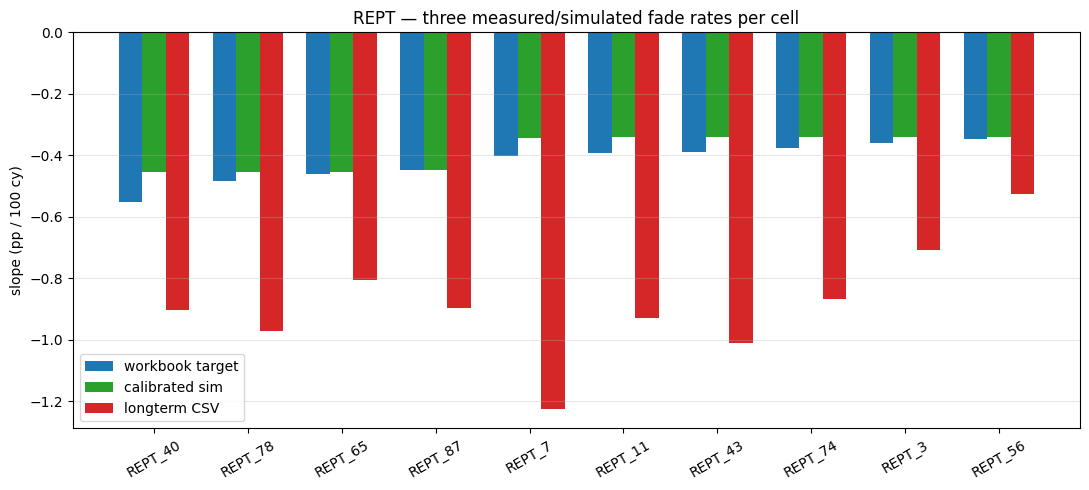

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(df))
w = 0.25
ax.bar(x - w, df["target slope"], w, label="workbook target", color="#1f77b4")
ax.bar(x,     df["sim slope"],   w, label="calibrated sim", color="#2ca02c")
ax.bar(x + w, df["CSV slope"],   w, label="longterm CSV",   color="#d62728")
ax.set_xticks(x); ax.set_xticklabels(df["cell"], rotation=30)
ax.set_ylabel("slope (pp / 100 cy)")
ax.axhline(0, ls="-", color="black", lw=0.6)
ax.set_title("REPT — three measured/simulated fade rates per cell")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 3. D_SEI distribution

REPT D_SEI clusters tightly (~1.07–1.54e-22 m²/s), much narrower than the
EVE cohort. The bracketing is a bisection-precision effect (rtol=0.20) —
tighten if you need finer separation.

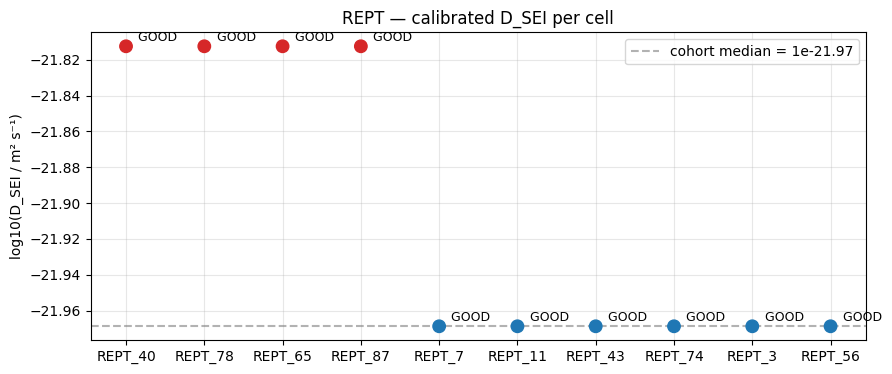

Outliers (>2σ MAD): ['REPT_40', 'REPT_78', 'REPT_65', 'REPT_87']


In [4]:
log_d = np.log10(df["D_SEI (m²/s)"].astype(float))
med = log_d.median()
mad = (log_d - med).abs().median() or 1e-12
is_outlier = (log_d - med).abs() > 2.0 * 1.4826 * mad

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#d62728" if o else "#1f77b4" for o in is_outlier]
ax.scatter(df["cell"], log_d, c=colors, s=80, zorder=3)
for _, r in df.iterrows():
    ax.annotate(f" {r.classification}", (r["cell"], np.log10(r["D_SEI (m²/s)"])),
                xytext=(6, 4), textcoords="offset points", fontsize=9)
ax.axhline(med, ls="--", color="grey", alpha=0.6,
            label=f"cohort median = 1e{med:.2f}")
ax.set_ylabel("log10(D_SEI / m² s⁻¹)")
ax.set_title("REPT — calibrated D_SEI per cell")
ax.legend()
ax.grid(alpha=0.3)
plt.show()
print("Outliers (>2σ MAD):", df[is_outlier]["cell"].tolist() or "—")

## 4. Sim vs measured — 2×5 grid across the cohort

Same chart as the EVE notebook, sized for 10 cells. The sim line shows
the calibrated PyBaMM trajectory; the red dots are the longterm CSV measurements
for the first 20 cycles.

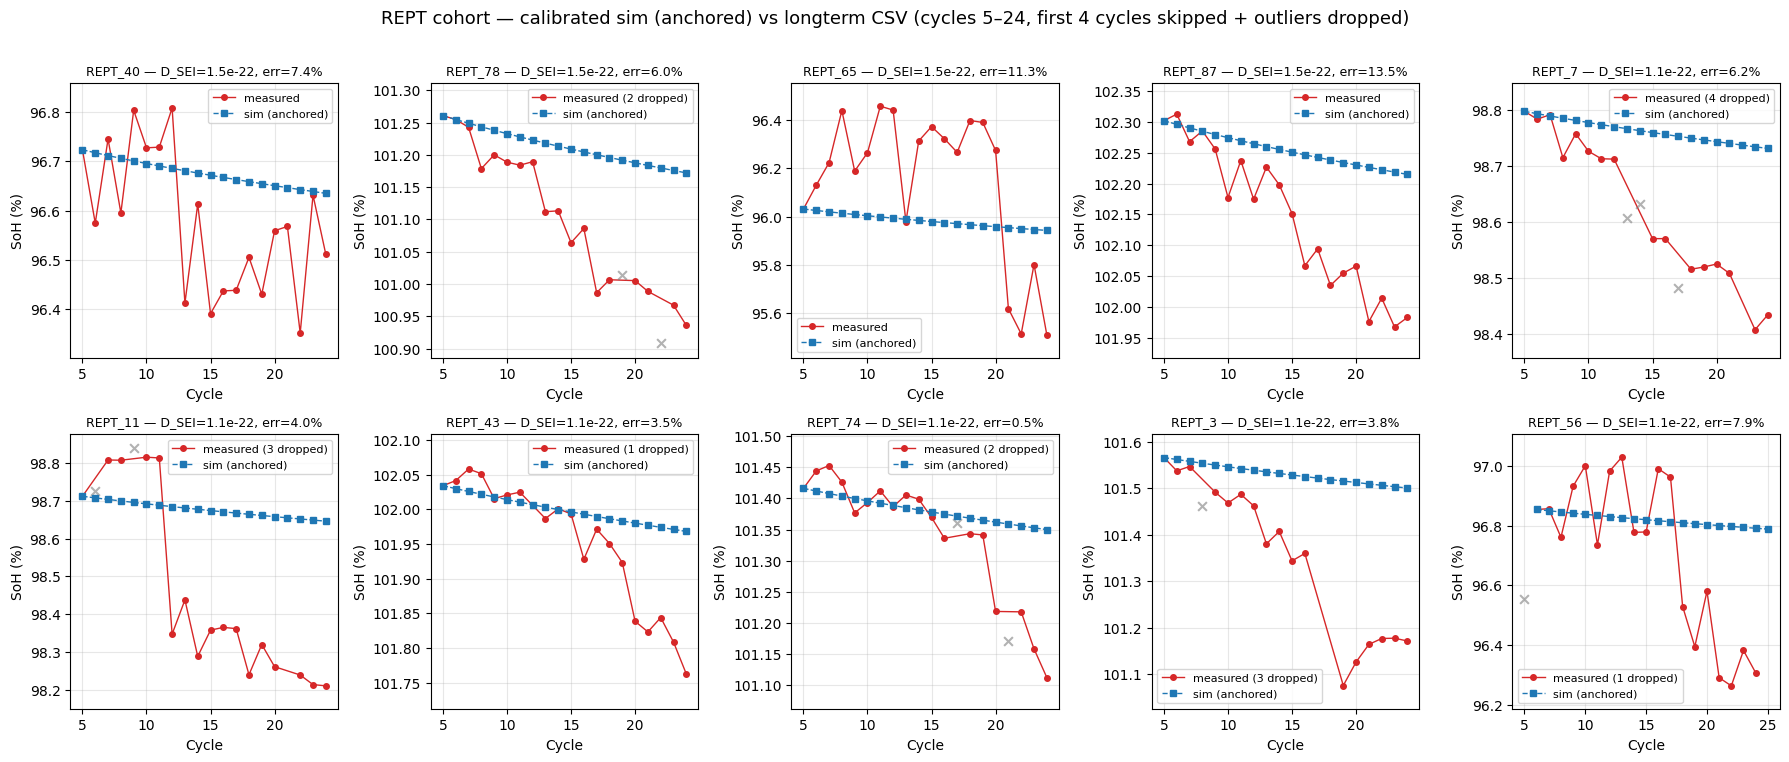

In [5]:
def _drop_outliers(series: pd.Series, k: float = 3.0,
                    window: int = 5) -> pd.Series:
    """Hampel filter — drop points that deviate from a rolling median by
    more than k * MAD. Robust to isolated cycler glitches (REPT_3 cycle 17
    is a textbook example: single point ~7 pp below the surrounding trace).
    """
    if len(series) < window:
        return pd.Series([True] * len(series), index=series.index)
    med = series.rolling(window, center=True, min_periods=1).median()
    mad = (series - med).abs().rolling(window, center=True, min_periods=1).median()
    threshold = k * 1.4826 * mad.clip(lower=1e-9)
    return (series - med).abs() <= threshold


# Skip the first N cycles — formation / equilibration phase where the
# cycler's reported dchg_cap jumps before settling into the real trajectory.
# Visible as a 0.3–0.6 pp step in nearly every panel.
SKIP_FIRST_N = 4

cells_sorted = df["cell"].tolist()
fig, axs = plt.subplots(2, 5, figsize=(18, 7.5))
axs = axs.flatten()
for i, tag in enumerate(cells_sorted):
    ax = axs[i]
    aging = json.loads((OUT_DIR / f"{tag}_aging_calibrated.json").read_text())

    per_cyc_path = OUT_DIR / f"{tag}_longterm_per_cycle.csv"
    meas = pd.read_csv(per_cyc_path) if per_cyc_path.exists() else None

    sim_parq = OUT_DIR / f"{tag}_calibrated_sim_20cy.parquet"
    sim_df = pd.read_parquet(sim_parq) if sim_parq.exists() else None

    if meas is not None and sim_df is not None:
        early = meas[meas.cycle_no.between(SKIP_FIRST_N + 1,
                                            SKIP_FIRST_N + 20)].copy()
        early["soh_pct"] = early["soh"] * 100.0

        # Outlier rejection — Hampel filter on the (post-skip) measured SoH
        keep = _drop_outliers(early["soh_pct"], k=3.0, window=5)
        n_dropped = int((~keep).sum())
        clean = early[keep]

        # Anchor sim to the (cleaned) measured value at the FIRST kept cycle
        # so both traces start from the same SoH and slopes are directly
        # comparable on a tight y-axis.
        sim_soh_pct = sim_df["SOH"].values * 100.0
        sim_cyc     = sim_df["cycle_n"].values.astype(float)
        first_cyc   = int(clean["cycle_no"].iloc[0])
        meas_start  = float(clean["soh_pct"].iloc[0])
        sim_anchored = sim_soh_pct + (meas_start - sim_soh_pct[0])
        sim_cyc_anchored = sim_cyc + (first_cyc - sim_cyc[0])

        ax.plot(clean.cycle_no, clean["soh_pct"], "o-", lw=1, ms=4,
                color="#d62728",
                label=f"measured ({n_dropped} dropped)" if n_dropped else "measured")
        if n_dropped:
            dropped = early[~keep]
            ax.scatter(dropped.cycle_no, dropped["soh_pct"], s=40,
                        marker="x", color="grey", alpha=0.6, zorder=2)
        ax.plot(sim_cyc_anchored, sim_anchored, "s--", lw=1, ms=4,
                color="#1f77b4", label="sim (anchored)")

        # Tight y-limits around the joint range
        all_y = np.concatenate([clean["soh_pct"].values, sim_anchored])
        pad = max(0.05, (all_y.max() - all_y.min()) * 0.1)
        ax.set_ylim(all_y.min() - pad, all_y.max() + pad)

    ax.set_title(f"{tag} — D_SEI={aging['calibrated_value']:.1e}, "
                  f"err={aging['relative_error_pct']:.1f}%", fontsize=9)
    ax.set_xlabel("Cycle")
    ax.set_ylabel("SoH (%)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=8)

fig.suptitle(f"REPT cohort — calibrated sim (anchored) vs longterm CSV "
              f"(cycles {SKIP_FIRST_N + 1}–{SKIP_FIRST_N + 20}, "
              f"first {SKIP_FIRST_N} cycles skipped + outliers dropped)",
              fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 5. CSV vs workbook — same cells, two windows

The CSV regression slope is consistently steeper than the workbook target.
That's expected: workbook averages over ~600 cycles (b1→b2), while the CSV
covers only the early ~150 cycles where SEI growth is fastest.

Ratio < 1 = CSV is shallower than target (sim model bias);
Ratio > 1 = CSV is steeper (formation-dominated early fade).

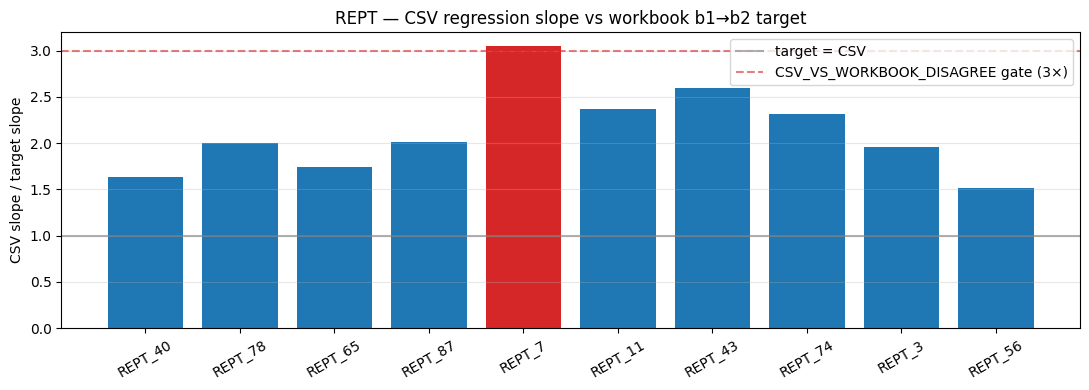

Median ratio: 2.01× (CSV is 2.0× steeper than workbook on average)


In [6]:
ratios = df["CSV slope"] / df["target slope"]
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(df["cell"], ratios, color=["#d62728" if r > 3 else "#1f77b4" for r in ratios])
ax.axhline(1.0, ls="-",  color="grey", alpha=0.6, label="target = CSV")
ax.axhline(3.0, ls="--", color="#d62728", alpha=0.6, label="CSV_VS_WORKBOOK_DISAGREE gate (3×)")
ax.set_ylabel("CSV slope / target slope")
ax.set_title("REPT — CSV regression slope vs workbook b1→b2 target")
ax.tick_params(axis="x", rotation=30)
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"Median ratio: {ratios.median():.2f}× (CSV is {ratios.median():.1f}× steeper than workbook on average)")

## 6. Per-cycle SoH trajectories — all 10 cells overlaid

Helpful to spot non-monotonic traces (like EVE_1 in the EVE cohort).
Expect REPT cells to be cleaner since they started fresh.

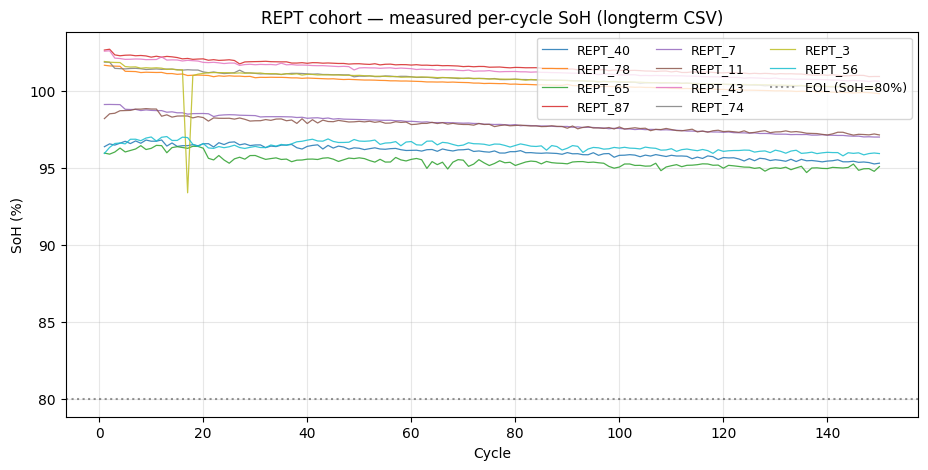

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
cmap = plt.cm.tab10
for i, tag in enumerate(cells_sorted):
    p = OUT_DIR / f"{tag}_longterm_per_cycle.csv"
    if not p.exists(): continue
    d = pd.read_csv(p)
    ax.plot(d.cycle_no, d.soh * 100.0, lw=0.9, alpha=0.85, color=cmap(i % 10), label=tag)
ax.axhline(80, ls=":", color="black", alpha=0.4, label="EOL (SoH=80%)")
ax.set_xlabel("Cycle"); ax.set_ylabel("SoH (%)")
ax.set_title("REPT cohort — measured per-cycle SoH (longterm CSV)")
ax.legend(ncols=3, loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
plt.show()

## 7. Gates audit

Which data-quality gates fired across the cohort. `✓` = tripped, `–` = not tripped.

In [8]:
gate_rows = []
for p in sorted(OUT_DIR.glob("REPT_*_aging_calibrated.json")):
    d = json.loads(p.read_text())
    row = {"cell": d["cell"]}
    for g, info in (d.get("gate_audit") or {}).items():
        row[g] = "✓" if (isinstance(info, dict) and info.get("tripped")) else "–"
    gate_rows.append(row)
gdf = pd.DataFrame(gate_rows).fillna("–").set_index("cell")
display(gdf)

,INVERTED_SLOPE,SHORT_LONGTERM,CSV_VS_WORKBOOK_DISAGREE,LOW_SOH_SIGNAL
cell,,,,
REPT_11,–,–,–,–
REPT_3,–,–,–,–
REPT_40,–,–,–,–
REPT_43,–,–,–,–
REPT_56,–,–,–,–
REPT_65,–,–,–,–
REPT_74,–,–,–,–
REPT_78,–,–,–,–
REPT_7,–,–,✓,–


## 8. Notes / next steps

**Cohort headline:**
- 10/10 GOOD. D_SEI clustered in 1.07–1.54e-22 m²/s.
- D_SEI median ~5× LOWER than the EVE cohort (3.16e-22 → 1.07e-22), reflecting REPT cells aging more slowly per workbook.
- The CSV slope is consistently ~2× the workbook target. Confirmed in the bar chart above; reflects faster early-cycle fade.

**Caveats to investigate:**
- D_SEI clustering at two discrete values is a bisection-precision artifact (rtol=0.20). Tighten via `rtol=0.05` in the sweep script if a finer distribution is needed.
- The `cycles_per_batch=600` convention from `pybamm_tuning` is unverified. If real b1→b2 interval is shorter, all targets scale inversely.

**Next:**
- Expand to all 21 paired REPT cells if the top-10 looks representative.
- Use the calibrated D_SEI per cell as input to PINN training (the eventual downstream consumer).